## Introducción

Como analista de datos, tu objetivo es **evaluar cómo la movilidad urbana se relaciona con la productividad económica en las principales ciudades latinoamericanas**. 
Para ello trabajarás con datos reales de TomTom Traffic Index y OECD Cities, que deberás limpiar, combinar y analizar para identificar en qué ciudades conviene invertir en infraestructura de transporte.

## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de ambos datasets**.
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯Objetivo:**
Importar las librerías necesarias, cargar los archivos CSV en DataFrames y realizar una revisión preliminar para entender su contenido.

**Instrucciones:**
- Importa las librerías `pandas`, `numpy`, `seaborn` y `matplotlib.pyplot`.
- Carga los archivos usando `pd.read_csv()`:
  - `'/datasets/tomtom_traffic.csv'`
  - `/datasets/oecd_city_economy.csv` `.
- Guarda los DataFrames en las variables `traffic` y `eco`.
- Muestra las primeras 5 filas de cada DataFrame.


In [ ]:

# importar librerías
import pandas as pd
pd.read_csv('/datasets/tomtom_traffic.csv')
pd.read_csv('/datasets/oecd_city_economy.csv')




,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"
3,2023,brasilia,Brazil,"15.999,00",8.3%,"13,50","4,70"
4,2023,salvador,Brazil,"8.761,00",13.1%,"16,00","3,90"
5,2023,fortaleza,Brazil,"838,00",12.5%,"15,40","4,20"
6,2023,belo-horizonte,Brazil,"10.951,00",10.1%,"17,50","6,00"
7,2023,curitiba,Brazil,"12.189,00",8.8%,"14,20","3,60"
8,2023,recife,Brazil,"9.047,00",11.8%,"16,50","4,10"
9,2023,porto-alegre,Brazil,"11.618,00",9.2%,"14,90","4,30"


In [ ]:



# cargar archivos
traffic = pd.read_csv('/datasets/tomtom_traffic.csv')
eco = pd.read_csv('/datasets/oecd_city_economy.csv'
)



In [ ]:


# mostrar las primeras 5 filas de traffic
print(traffic.head(5))





  Country       City            UpdateTimeUTC  JamsDelay  TrafficIndexLive  \
0     ARE  abu-dhabi  2025-01-13 04:01:30.001      650.7              36.0   
1     ARE  abu-dhabi  2025-01-13 03:46:00.000      540.4              30.0   
2     ARE  abu-dhabi  2025-01-13 02:46:30.000       71.8               7.0   
3     ARE  abu-dhabi  2025-01-13 01:46:30.001        8.2               2.0   
4     ARE  abu-dhabi  2025-01-13 00:01:30.000        1.1               1.0   

   JamsLengthInKms  JamsCount  TrafficIndexWeekAgo     UpdateTimeUTCWeekAgo  \
0            109.1      162.0                 30.0  2025-01-06 04:01:30.000   
1            101.4      136.0                 27.0  2025-01-06 03:46:30.001   
2             18.9       23.0                  6.0  2025-01-06 02:46:30.000   
3              4.1        2.0                  2.0  2025-01-06 01:46:30.000   
4              0.2        1.0                  1.0  2025-01-06 00:01:30.000   

   TravelTimeLivePer10KmsMins  TravelTimeHistoricPer10Km

In [ ]:


# mostrar las primeras 5 filas de eco
print(eco.head(5))



   Year            City    Country City GDP/capita Unemployment %  \
0  2023    buenos-aires  Argentina       15.782,00           6.2%   
1  2023       sao-paulo     Brazil       14.475,00           9.1%   
2  2023  rio-de-janeiro     Brazil       13.142,00           9.8%   
3  2023        brasilia     Brazil       15.999,00           8.3%   
4  2023        salvador     Brazil        8.761,00          13.1%   

  PM2.5 (μg/m³) Population (M)  
0          15,2          15,30  
1         29,50          22,50  
2         19,10          13,60  
3         13,50           4,70  
4         16,00           3,90  


**Tip:** Si no usas `print()` la tabla se vera mejor.


---

## 🧩Paso 2: Explorar, limpiar y preparar los datos

Antes de combinar los datasets, inspecciona su estructura, tipos de datos, columnas y valores faltantes.
Anota las columnas que necesiten limpieza y luego estandariza los nombres de columnas.

### 2.1 Explorar la estructura y tipos de datos

**🎯Objetivo:**
Identificar columnas con tipos incorrectos, distribución y nulos, anotar las columnas que requieren conversión.

**Instrucciones:**

- Usa `.info()` para conocer la estructura de ambos DataFrames.
- Muestra los primeros 3 renglones de cada DF.
- Identifica si los detalles de cada DF estan bien o si requieren correcciones y escribe tus conclusiones en el bloque Markdown.
  - ¿Hay columnas que requieren conversión?¿ Cuáles son? ¿Que tipo de dato ienen y cuál deberían de tener?
 
  - 
Efectivamente hay columnas que debemos convertir como es el caso de UpdateTimeUTC y UpdateTimeUTCWeekAgo que estan como tipo object "texto" deberiamos confertirlas a tipo datetime
    
  - ¿Hay datos ausentes en alguna columna?
 
NO 


In [ ]:



# Examinar la estructura de traffic
traffic.info()





<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   Country                         1004464 non-null  object 
 1   City                            1004464 non-null  object 
 2   UpdateTimeUTC                   1004464 non-null  object 
 3   JamsDelay                       1004464 non-null  float64
 4   TrafficIndexLive                1004464 non-null  float64
 5   JamsLengthInKms                 1004464 non-null  float64
 6   JamsCount                       1004464 non-null  float64
 7   TrafficIndexWeekAgo             1004464 non-null  float64
 8   UpdateTimeUTCWeekAgo            1004464 non-null  object 
 9   TravelTimeLivePer10KmsMins      1004464 non-null  float64
 10  TravelTimeHistoricPer10KmsMins  1004464 non-null  float64
 11  MinsDelay                       1004464 non-null  float64
dtype

En la estructura del DF traffic, se observa que:
- Las columnas `UpdateTimeUTC` y `UpdateTimeUTCWeekAgoo` son de tipo object, pero para obtener un analisis temporal correcto deberiamos usar el datetime.
- ...

In [ ]:
# Examinar la estructura de eco
eco.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Year             30 non-null     int64 
 1   City             30 non-null     object
 2   Country          30 non-null     object
 3   City GDP/capita  30 non-null     object
 4   Unemployment %   30 non-null     object
 5   PM2.5 (μg/m³)    30 non-null     object
 6   Population (M)   30 non-null     object
dtypes: int64(1), object(6)
memory usage: 1.8+ KB





En la estructura del DF eco, se observa que:
- Las columnas `City GDP/capita`, `Unemployment %` y Population son de tipo object, es decir pandas lo esta tomando como texto, pero deberian ser float para poder obtener calculos matematicos que nos ayuden con nuestro anlaisis, por lo tanto deberiamos verificar estas columnas par visualizar si hay algun caracter (comas, espacios, etc.) que no permite que sean tomadas como float.
- ... 




### 2.2 Renombrar columnas

**🎯Objetivo:**
Estandarizar los nombres de columnas para evitar errores y facilitar la unión de los datasets.

**Instrucciones:**

- Cambia los nombres de las columnas para que tengan el formato `snake_case`.
    - `Country` → `country`
    - `UpdateTimeUTC` → `update_time_utc`
- Verifica que los cambios se hayan aplicado correctamente usando `.columns`.


In [ ]:

# Estandarizar los nombres de las columnas de traffic
#tu código aquí
traffic = traffic.rename(columns={"Country": "country", "UpdateTimeUTC": "update_time_utc"})

# verificar cambios
traffic.columns


Index(['country', 'City', 'update_time_utc', 'JamsDelay', 'TrafficIndexLive',
       'JamsLengthInKms', 'JamsCount', 'TrafficIndexWeekAgo',
       'UpdateTimeUTCWeekAgo', 'TravelTimeLivePer10KmsMins',
       'TravelTimeHistoricPer10KmsMins', 'MinsDelay'],
      dtype='object')

In [ ]:

# Estandarizar los nombres de las columnas de eco
#tu código aquí
eco = eco.rename(columns={"Country": "country", "UpdateTimeUTC": "update_time_utc"})
# verificar cambios
eco.columns


Index(['Year', 'City', 'Country', 'City GDP/capita', 'Unemployment %',
       'PM2.5 (μg/m³)', 'Population (M)'],
      dtype='object')


### 2.3 Corregir formatos numéricos y de fecha

**🎯Objetivo:**
Asegurar que las columnas de fechas y valores numéricos estén en formatos correctos para permitir análisis, cálculos y comparaciones precisas.

**Instrucciones:**

- Convierte las columnas de fecha de `traffic` a formato `datetime`. Haz el cambio a prueba de errores.
- En el dataset `eco`, limpia los valores numéricos:
    - En `city_gdp_capita`: elimina separadores de miles (`.`) y reemplaza las comas (`','`) por puntos (`'.'`) antes de convertir a tipo `float`.
    - En `unemployment_pct`: elimina el símbolo de porcentaje (`%`) y reemplaza las comas (`','`) por puntos (`'.'`) antes de convertir a tipo `float`.
    - En `population_m`: reemplaza las comas (`','`) por puntos (`'.'`) antes de convertir a tipo `float`.
- Finalmente, crea una nueva columna llamada `population` multiplicando `population_m` por 1,000,000 para obtener la población total.


<details>
<summary>Haz clic para ver la pista</summary>
para eliminar símbolos, puedes reemplazarlos por un texto vacío.

In [ ]:

# Convertir las columnas de traffic a tipo fecha con pd.to_datetime()
traffic['update_time_utc'] = pd.to_datetime(traffic['update_time_utc']) #tu código aquí
traffic['UpdateTimeUTCWeekAgo'] = pd.to_datetime(traffic['UpdateTimeUTCWeekAgo']) #tu código aquí

# verificar el cambio
traffic.info(pd.to_datetime)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 13 columns):
 #   Column                          Non-Null Count    Dtype         
---  ------                          --------------    -----         
 0   country                         1004464 non-null  object        
 1   City                            1004464 non-null  object        
 2   update_time_utc                 1004464 non-null  datetime64[ns]
 3   JamsDelay                       1004464 non-null  float64       
 4   TrafficIndexLive                1004464 non-null  float64       
 5   JamsLengthInKms                 1004464 non-null  float64       
 6   JamsCount                       1004464 non-null  float64       
 7   TrafficIndexWeekAgo             1004464 non-null  float64       
 8   UpdateTimeUTCWeekAgo            1004464 non-null  datetime64[ns]
 9   TravelTimeLivePer10KmsMins      1004464 non-null  float64       
 10  TravelTimeHistoricPer10KmsMins  1004464 no

In [ ]:


# Limpia separadores y convierte columnas numéricas en eco
# eco['city_gdp_capita'] = ....astype(str).str.replace('.', '').str.replace(',', '.').astype(float)
eco['city_gdp_capita'] = eco['City GDP/capita'].astype(str).str.replace('.', '').str.replace(',', '.').astype(float)
# eco['unemployment_pct'] = ...
eco['unemployment_pct'] = eco['Unemployment %'].astype(str).str.replace('%', '').str.replace(',', '.').astype(float)
# eco['population_m'] = ...
eco['population_m'] = eco['Population (M)'].astype(str).str.replace(',', '.').astype(float)
# Calcula la población total en unidades absolutas (Multiplica * 1000000)
# eco['population'] = ...
eco['population'] = eco['population_m'] * 1000000
# verificar el cambio
eco.info()
eco.head(3)



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Year              30 non-null     int64  
 1   City              30 non-null     object 
 2   Country           30 non-null     object 
 3   City GDP/capita   30 non-null     object 
 4   Unemployment %    30 non-null     object 
 5   PM2.5 (μg/m³)     30 non-null     object 
 6   Population (M)    30 non-null     object 
 7   city_gdp_capita   30 non-null     float64
 8   unemployment_pct  30 non-null     float64
 9   population_m      30 non-null     float64
 10  population        30 non-null     float64
dtypes: float64(4), int64(1), object(6)
memory usage: 2.7+ KB


,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M),city_gdp_capita,unemployment_pct,population_m,population
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30",15782.0,6.2,15.3,15300000.0
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50",14475.0,9.1,22.5,22500000.0
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60",13142.0,9.8,13.6,13600000.0



---

## 🧩Paso 3: Extraer año y filtrar

Extraer el año permite filtrar la información y trabajar solo con el período más reciente y relevante.

### 3.1 Extraer columna año y filtrar 2024

**🎯Objetivo**
Identificar el año de cada registro y mantener solo los registros del 2024.

**Intrucciones**

- Como el DataFrame `traffic` no tiene una columna de año, utiliza el atributo `.dt.year` sobre su columna de fecha para crear una nueva columna llamada `year`.
- Filtra las filas donde el año sea **2024**.
- Utiliza `.copy()` para crear dos nuevos DataFrames (`traffic_2024` y `eco_2024`) para evitar modificar el dataset original.

In [ ]:


# Extraer el año de las fechas en update_time_utc
# traffic['year'] = ...
traffic['year'] = traffic['update_time_utc'].dt.year

# Verificar cambio
traffic.head(3)



,country,City,update_time_utc,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay,update_time_utc_week_ago,year
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437,2025-01-06 04:01:30.000,2025
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635,2025-01-06 03:46:30.001,2025
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232,2025-01-06 02:46:30.000,2025


In [ ]:

# Filtra los registros del año 2024
# traffic_2024 = traffic[...].copy()
# eco_2024 = ...
traffic_2024 = traffic[traffic['year'] == 2024].copy()
eco_2024 = eco[eco['Year'] == 2024].copy()
# Revisar dataframes nuevos
display(traffic_2024.head())
display(eco_2024.head())



,country,City,update_time_utc,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay,update_time_utc_week_ago,year
302,ARE,abu-dhabi,2024-12-31 23:01:30.000,12.9,5.0,2.5,5.0,2.0,2024-12-24 23:01:30.001,8.560399,8.519634,0.040765,2024-12-24 23:01:30.001,2024
303,ARE,abu-dhabi,2024-12-31 22:01:30.000,136.0,21.0,20.6,32.0,3.0,2024-12-24 22:01:30.000,10.355732,9.049445,1.306286,2024-12-24 22:01:30.000,2024
304,ARE,abu-dhabi,2024-12-31 21:16:30.000,455.2,31.0,40.4,72.0,4.0,2024-12-24 21:01:30.000,11.456878,9.305174,2.151704,2024-12-24 21:01:30.000,2024
305,ARE,abu-dhabi,2024-12-31 20:01:00.001,399.4,27.0,38.0,75.0,6.0,2024-12-24 20:01:30.001,11.670062,9.952811,1.717252,2024-12-24 20:01:30.001,2024
306,ARE,abu-dhabi,2024-12-31 19:46:00.000,366.4,28.0,39.8,82.0,9.0,2024-12-24 19:01:00.000,11.686322,10.008469,1.677853,2024-12-24 19:01:00.000,2024


,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M),city_gdp_capita,unemployment_pct,population_m,population
15,2024,buenos-aires,Argentina,"18.117,00",7.2%,"14,50","15,40",18117.0,7.2,15.4,15400000.0
16,2024,sao-paulo,Brazil,"14.703,00",8.5%,"28,00","22,60",14703.0,8.5,22.6,22600000.0
17,2024,rio-de-janeiro,Brazil,"13.349,00",9.2%,"18,40","13,70",13349.0,9.2,13.7,13700000.0
18,2024,brasilia,Brazil,"16.251,00",7.8%,"12,80","4,80",16251.0,7.8,4.8,4800000.0
19,2024,salvador,Brazil,"8.899,00",12.4%,"15,20","3,90",8899.0,12.4,3.9,3900000.0



---

## 🧩Paso 4: Analizar y resumir datos de movilidad

Como el dataset de tráfico contiene **múltiples registros por ciudad**. En esta parte, calcularás los promedios anuales por ciudad para simplificar el análisis y obtener una visión más clara de las tendencias generales.

### 4.1 Calcular promedios de tráfico por ciudad

**🎯Objetivo:**
Obtener una vista consolidada del tráfico promedio por ciudad y año, para analizar patrones generales sin depender de datos diarios.

**Instrucciones**

- Agrupa los datos por `city`, `country` y `year`.
- Calcula el promedio **solo de las métricas de tráfico más relevantes**: como `jams_delay`, `traffic_index_live`, `jams_length_kms`, `jams_count`, `mins_delay`, y tiempos de viaje (`travel_time_live_per_10kms_mins` y `travel_time_hist_per_10kms_mins`).
- Guarda el resultado como `traffic_city_year_2024`, mantén las columnas como variables (no índices).


<details>
<summary>Haz clic para ver la pista</summary>
Usa ".agg()" para aplicar funciones de promedio. Al final, reinicia el índice para mantener las columnas de la agrupación como variables (no índices).

In [ ]:

# Calcular los  promedios de trafico por ciudad, país y año
traffic_city_year_2024 = traffic_2024.groupby(['City', 'country', 'year'], as_index=False).agg({
    'JamsDelay': 'mean',
    'TrafficIndexLive': 'mean',
    'JamsLengthInKms': 'mean',
    'JamsCount': 'mean',
    'MinsDelay': 'mean',
    'TravelTimeLivePer10KmsMins': 'mean',
    'TravelTimeHistoricPer10KmsMins': 'mean'
    })
# Mostrar resultado
traffic_city_year_2024.head()


,City,country,year,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,MinsDelay,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins
0,a-coruna,ESP,2024,17.935187,15.259774,2.198002,4.934405,0.774172,16.267977,15.493804
1,aachen,DEU,2024,26.732141,20.960314,3.892586,6.601832,0.792968,13.397861,12.604894
2,aarhus,DNK,2024,21.200616,16.575891,2.736736,6.109987,0.495276,15.219292,14.724016
3,abu-dhabi,ARE,2024,171.157315,13.902028,24.507380,47.268019,0.139764,9.829092,9.689328
4,adana,TUR,2024,83.864761,22.541040,11.827331,23.754620,1.129749,15.879694,14.749945


### 🧠 **Momento de reflexión**

¡Excelente trabajo hasta aquí!

Ahora que ya tienes los promedios anuales por ciudad, es momento de **observarlos** con atención.

Piensa:

- ¿Cuál crees que tiene el mayor tiempo promedio de tráfico?
- ¿Será una ciudad de **Europa**, de **Latinoamérica** o de **otra región** del mundo?

Para descubrirlo, ejecuta esta línea de código:

`traffic_city_year_2024.sort_values(["jams_delay"], ascending=False)`


🔍 Observa qué ciudad aparece en los primeros lugares.

¿Te sorprenden los resultados? , ¿Coinciden con lo que imaginabas?

In [ ]:
traffic_city_year_2024.sort_values(["JamsDelay"], ascending=False)

,City,country,year,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,MinsDelay,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins
221,mexico-city,MEX,2024,2833.057892,34.218190,389.239265,594.969392,1.855542,21.809092,19.953550
352,tokyo,JPN,2024,2152.574357,36.805059,373.069734,518.809420,0.698152,22.443778,21.745626
246,new-york,USA,2024,2133.400000,28.210388,398.227892,544.474902,1.396351,18.505043,17.108691
200,london,GBR,2024,2050.703662,29.230166,287.632868,471.795554,1.325160,17.714139,16.388979
211,manila,PHL,2024,1741.493381,66.129402,246.858082,341.881205,2.469894,27.134629,24.664734
...,...,...,...,...,...,...,...,...,...,...
111,dunedin,NZL,2024,4.651175,15.430809,0.712315,1.591384,0.633294,16.226009,15.592715
363,uppsala,SWE,2024,4.194486,13.939168,0.656368,1.349672,0.501802,15.746717,15.244916
123,fujairah,ARE,2024,4.025959,10.907719,0.731910,1.373006,0.194951,11.662590,11.467639
12,almere,NLD,2024,3.633523,6.290478,0.506362,1.064063,-0.017544,9.467150,9.484694


La ciudad con el mayor tiempo promedio de tráfico es mexico-city ocupando el primer lugar con un promedio del 2,833 % de retraso por congestion, en segundo lugar tenemos a tokyo con el 2,152 % de congestion por lo que podemos observar que en cuanto a congestion de movilidad se pociciona en primer lugar un pais de latinoamerica.


---

## 🧩Paso 5: Unir movilidad y economía

Combinar datasets te permite analizar cómo se relacionan los indicadores económicos con los de movilidad.

### 5.1 Unir tráfico (tabla principal) con indicadores económicos

**🎯Objetivo:**
Combinar la información de tráfico y economía en un solo DataFrame para analizar cómo las condiciones económicas se relacionan con la movilidad urbana.

**Instrucciones**
- Selecciona solo las **columnas relevantes** de cada dataset (por ejemplo, variables clave de tráfico y de economía).
- Usa `.copy()` al crear subconjuntos para evitar modificar el dataset original.
- Une ambos DataFrames y define como **claves de unión** a `city` y `year`.
- Mantén solo las ciudades y años presentes en ambos datasets.
- Guarda el resultado en una nueva variable llamada `merged` y muestra las primeras 5 filas.


<details>
<summary>Haz clic para ver la pista</summary>
Aplica una unión de tipo "inner" para mantener las ciudades y años presentes en ambos datasets.

In [ ]:




# Seleccionar columnas clave de tráfico y economía

left_cols = ['City','country','year','JamsDelay','TrafficIndexLive',
             'JamsLengthInKms','JamsCount','MinsDelay',
             'TravelTimeLivePer10KmsMins','TravelTimeHistoricPer10KmsMins']

right_cols = ['City','Year','city_gdp_capita','unemployment_pct','PM2.5 (μg/m³)','population']

# Usar .copy() para crear los dos nuevos datasets reducidos
# traffic_2024_small = traffic_city_year_2024[ ... ].copy()
# eco_2024_small = ...

traffic_2024_small = traffic_city_year_2024[left_cols].copy()
eco_2024_small = eco_2024[right_cols].copy()

# Unir datasets
 # tu código aquí
merged = traffic_2024_small.merge(eco_2024_small, left_on=['City', 'year'], right_on=['City', 'Year'], how='inner')
# Mostrar las primeras 5 filas

print(merged.head())
# tu código aquí




             City country  year    JamsDelay  TrafficIndexLive  \
0  belo-horizonte     BRA  2024   263.047879         19.428946   
1          bogota     COL  2024  1141.552364         37.614273   
2        brasilia     BRA  2024   101.576326         11.258220   
3    buenos-aires     ARG  2024   571.089593         17.756012   
4        curitiba     BRA  2024   183.469274         14.954545   

   JamsLengthInKms   JamsCount  MinsDelay  TravelTimeLivePer10KmsMins  \
0        44.038129   68.805422   0.487228                   18.304538   
1       140.893564  230.566550   1.699628                   24.992185   
2        18.337133   27.280140   0.193442                   13.338658   
3       100.287844  137.359860   0.416566                   17.907916   
4        30.050044   46.898164   0.139965                   17.258700   

   TravelTimeHistoricPer10KmsMins  Year  city_gdp_capita  unemployment_pct  \
0                       17.817311  2024          11124.0               9.5   
1       

<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Ejecutaste correctamente la operación de _merge_ utilizando `pd.merge(..., on=['city', 'year'], how='inner')`. Esta unión es apropiada cuando se desea trabajar únicamente con las observaciones presentes en ambos DataFrames y mantener consistencia en las claves de análisis.

</div>


---

## 🧩Paso 6: Visualización y análisis de relaciones

Ahora que tienes un dataset limpio y unificado, es momento de **visualizar patrones**.
Los gráficos te ayudarán a entender cómo se relacionan las variables económicas con las de movilidad urbana.

### 6.1 Visualizar relaciones entre economía y tráfico

**🎯Objetivo:**
Analizar visualmente la distribución y la relación entre indicadores de tráfico y economía en 2024, para identificar posibles patrones o tendencias generales entre ambas variables.

**Instrucciones**
- Usa las librerías `seaborn` y `matplotlib.pyplot` para generar los gráficos.
- Visualiza la distribución del **tráfico** (`jams_delay`) mediante:
    - **Boxplot** → para observar la media, mediana y detectar valores atípicos.
- Visualiza la distribución de la **economía** (`city_gdp_capita`) mediante:
    - **Histograma** → para analizar la forma de la distribución y el valor promedio del PIB per cápita.
- Finalmente, **compara ambas variables**, para observar si existe alguna relación entre ellas, haciendo un solo gráfico de barras donde aparezcan ambos indicadores.
- Recuerda agregar título y etiquetas a los ejes de tus gráficos.
- Observa y comenta los patrones, valores extremos o posibles relaciones que identifiques.

**Tip:** Dentro de los parentesis del boxplot, agrega `showmeans=True` para ver la media en el gráfico.

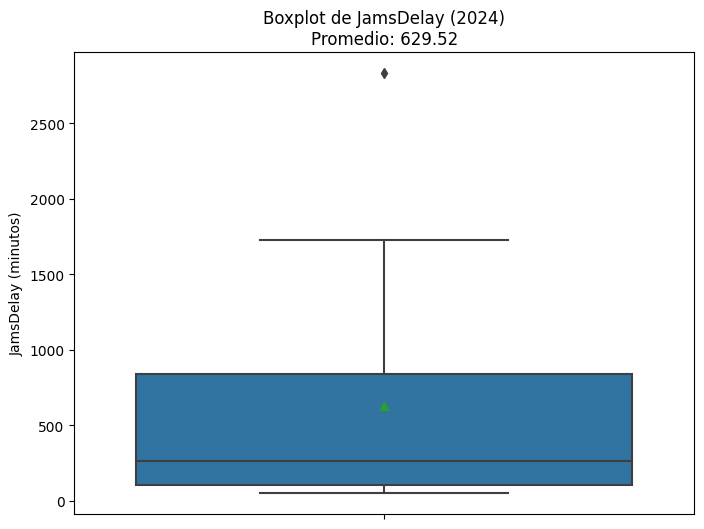

In [ ]:
# Crear boxplot para observar el comportamiento de los minutos de congestion JamsDelay
# crea tu gráfico
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# obtener promedio para mostrarlo en título
mean_value = merged['JamsDelay'].mean()



plt.figure(figsize=(8, 6))
sns.boxplot(data=merged, y='JamsDelay', showmeans=True)
plt.title(f'Boxplot de JamsDelay (2024)\nPromedio: {mean_value:.2f}')
plt.ylabel('JamsDelay (minutos)')
plt.show()





<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

La visualización es adecuada para comparar la distribución de las variables y detectar outliers, rangos y diferencias entre grupos. Utilizar este tipo de gráfico demuestra un enfoque sólido para el análisis exploratorio.

</div>

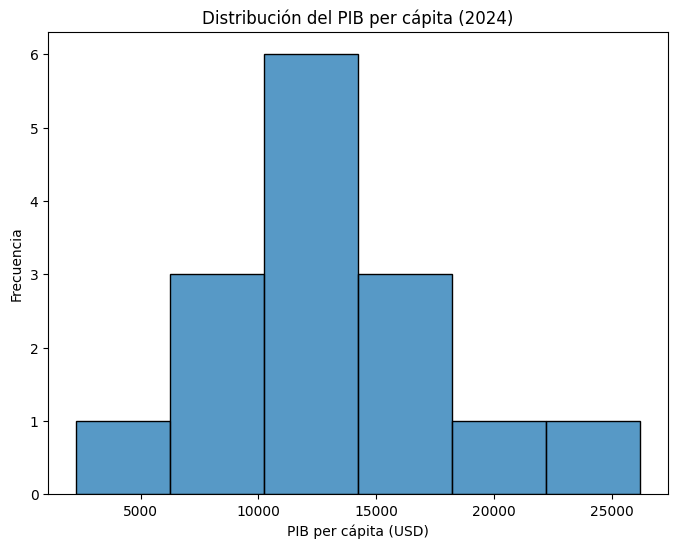

In [ ]:
# Crear histograma para ver la distribución de la economía (city_gdp_capita)
plt.figure(figsize=(8, 6))
sns.histplot(data=merged, x='city_gdp_capita')
plt.title('Distribución del PIB per cápita (2024)')
plt.xlabel('PIB per cápita (USD)')
plt.ylabel('Frecuencia')
plt.show()



<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Generaste correctamente el histograma de PIB per cápita y añadiste etiquetas adecuadas. Esta visualización es útil para entender la distribución de la variable, detectar sesgos y evaluar la presencia de valores atípicos.

</div>

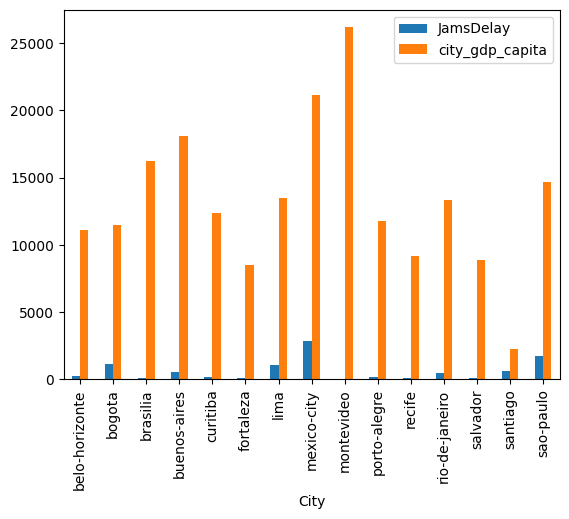

In [ ]:
# Gráfico de barras para comparar jams_delay y city_gdp_capita por ciudad
#merged.plot( ... , y=['jams_delay', 'city_gdp_capita'])
merged.plot(kind='bar', x='City', y=['JamsDelay', 'city_gdp_capita'])
plt.xticks(rotation=90)
plt.show()

**Tip:** Antes del `plt.show()` agrega el código `plt.xticks(rotation=90)` para rotar las etiquetas del eje X en 90 grados.

### 🧠 **Reflexiona**
Excelente trabajo llegando a esta etapa del análisis. Antes de avanzar, revisa tus gráficos, tómate un momento para pensar:

* ¿Las ciudades con mayor PIB per cápita también presentan más congestión?

* ¿O sucede lo contrario, o no existe una relación clara?

Escribe tus comentarios: Las ciudades con mayor PBI percapita no necesariamente presentan una mayor congestion como es el caso de montevideo ya que tiene un valor percapita alto y una baja congestion por lo que concluyo que la relacion no es muy clara.


---

## 🧩Paso 7: Exportar y documentar resultados

En esta etapa final consolidarás todo tu trabajo: guardarás el dataset limpio y crearás un resumen que documente los resultados del proyecto.

### 7.1 Guardar dataset final

**🎯Objetivo:**
Generar un CSV limpio, reproducible y con columnas relevantes para análisis posterior.

**Instrucciones**

- Exporta el DataFrame `merged` con el nombre: `ladb_mobility_economy_2024_clean.csv`
- Usa `index=False` para no incluir el índice.


In [ ]:
# Exporta el dataset final como CSV
merged.to_csv("ladb_mobility_economy_2024_clean.csv", index=False)

Para poder ver o descargar el archivo generado:   
En el menú lateral que esta a la izquierda, ve hasta la parte de abajo, a la sección de **Exportar dataset** para más información. 


---

## ✅ Entregables

1. **Notebook `.ipynb`** con todas las celdas (código + comentarios).
2. **CSV final**: `ladb_mobility_economy_2024_clean.csv`.
3. **Resumen ejecutivo breve** en Markdown (3–5 párrafos).



---

# 🧾 Resumen ejecutivo (plantilla)

> Completa este resumen al finalizar el análisis. Mantén 3–5 párrafos cortos, claros y accionables.

**Contexto & objetivo:**  
- Responde la pregunta central del análisis: ¿qué relación existe entre la movilidad urbana (congestión, tiempos de viaje) y la productividad económica (PIB per cápita)?

cocluimos que cuando hay una alta actividad económica genera mayor movimiento de bienes y personas. Sin embargo, cuando la infraestructura no escala al mismo ritmo que el PIB, la movilidad se convierte en un "impuesto oculto" que genera retrasos de hasta 2,800 minutos (como muestra el valor atípico del boxplot), restando horas productivas al trabajador.

Por otro lado esto demuestra que la productividad económica no causa inevitablemente la congestión. La planificación urbana y la densidad poblacional permiten que una ciudad sea rica sin sacrificar la movilidad.



- Explica brevemente las variables clave utilizadas y su relevancia para la toma de decisiones.
  
las variables que tome para analizar fueron: congestin, PBI per´cápita, tiempos de traslado y por último la calidad del aire, a continuación realizare una breve descripción de estas variables.

En primer lugar tenemos la variable congestión la cual esta asociada a una infraestructura deficiente para albergar el flujo de vehiculos, reduciendo asi la productividad economica de la ciudad, a su vez al tener un infraestructura defiente para el transporte hace que el tiempo de traslado de una persona de un lugar a otro sea mayor.
Por ultimo, un dato muy importante y no menos relevante es la calidad del aire ya que en aquellas ciudades con mayor congestion la calidad del aire es poco saludable por que hay mayor contaminacin del aire ocacionadas principalmente por los motores de los vehiculos (especialmente el disel).

**Cobertura de datos:**  
- Especifica los años analizados, número de ciudades y países incluidos.

En un principio realizamos un filtro para analizar especificamente el año 2024, con un total de 387 ciudades con sus respectivos paises, pero como nuestro principal objetivo es analizar aquellas ciudades que se encuentran el latinoamerica por eso cuando aplicamos el merge nos arrojo 15 ciudades  que estan distribuidas de la siguiente manera:
Brasil: 9 ciudades (belo-horizonte, brasilia, curitiba, fortaleza, porto-alegre, recife, rio-de-janeiro, salvador, sao-paulo)
Colombia: 1 ciudad (bogota)
Argentina: 1 ciudad (buenos-aires)
México: 1 ciudad (mexico-city)
Perú: 1 ciudad (lima)
Uruguay: 1 ciudad (montevideo)
Chile: 1 ciudad (santiago)

En conclusión podemos observar que Brasil cuenta con una mayor representación (60%) con respecto a los demas paises que solamente cuentan con una minima representación, lo que dificulta un poco la toma de decision del banco para invertir en infraestructura de transporte en Latinoamerica ya que no tenemos una representacion equilibrada entre los paises analizados, por lo que nos genera una limitacion geografica.


**Metodología (alto nivel):**  
- Describe los procesos principales: limpieza de datos (formatos, estandarización de columnas)

Se estandarizo los nombres de columnas a formato snake_case
Conversión de tipos de datos (fechas a datetime, valores numéricos con formato correcto), por lo que las columnas UpdateTimeUTC y UpdateTimeUTCWeekAgoo son de tipo object, pero para obtener un analisis temporal correcto deberiamos usar el datetime, por otro lado, las columnas City GDP/capita, Unemployment % y Population son de tipo object, es decir pandas lo esta tomando como texto, pero deberian ser float para poder obtener calculos matematicos que nos ayuden con nuestro anlaisis, por lo tanto deberiamos verificar estas columnas par visualizar si hay algun caracter (comas, espacios, etc.) que no permite que sean tomadas como float, por lo que se procede a la eliminación de separadores de miles y símbolos de porcentaje



- Explica la agregación por ciudad–año y el uso de una unión INNER para integrar tráfico y economía.


Extracción del año 2024 para análisis temporal específico
Agregación por ciudad-año calculando promedios de métricas de tráfico
Reducción de 1,004,464 registros a 387 ciudades promediadas, las metricas que utilizamos fueron  jams_delay, traffic_index_live, jams_length_kms, jams_count, mins_delay, y tiempos de viaje (travel_time_live_per_10kms_mins y travel_time_hist_per_10kms_min

Integración de datasets:
utilizamos la unión INNER entre datos de tráfico y economía para que nos arrojara los datos completos para poder hacer una comparativa entre congestion y PIB.
Llave de unión: ciudad (city) y año (year)
Resultado: 15 ciudades latinoamericanas con datos completos

  
- Menciona las validaciones visuales empleadas (distribuciones, outliers, tendencias generales).

**boxplots**:La variable que utilizamos fue (JamsDelay) para analizar los datos, asi mismo usamos showmeans=True para visualizar para la media, mediana y detectar valores atípicos, ademas este grafico nos ayuda a detectar e identificar la dispersion y los cuartiles de los datos. 

**histogramas**: Con este grafico analizamos la distribución del PBI per capita (2024) presenta una forma unimodal, ya que muestra un solo pico principal ubicado aproximadamente entre 12.000 y 14.000 USD es alli donde se concreta la mayor frecuencia de los datos. Ademas, la distribución sesgada ligeramente a la derecha (sesgo positivo), debido a que se observa una cola mas larga hacia los valores altos PBI per cápita superiores a 20.000 USD mientras que a los valores bajos la extencion es menor. Indicando que la mayoria de los paises se concentran en niveles medios del PBI per capita.



**gráficos de barras**: Este grafico nos permite comparar ambas variables, con el fin de identificar si existe alguna relación entre ellas con sus respectivos indicadores, el cual sugiere que un mayor desarrollo económico (PIB) no siempre implica más tráfico.
Lo primero que se nota es que los valores del PIB per cápita son significativamente más altos que los de retrasos por tráfico. Mientras que el PIB llega hasta los 25,000, los retrasos apenas son visibles en la base para la mayoría de las ciudades, lo que dificulta ver una correlación directa a simple vista.



**Hallazgos iniciales:**  
- Resumiendo los patrones más importantes entre índices de tráfico y PIB per cápita.

Para resumir los patrones los voy a lista 
1. Distribución económica regional:
La mayoría de las 15 ciudades latinoamericanas se concentran en niveles medios de PIB per cápita (12,000-14,000 USD)
Distribución sesgada hacia la derecha con algunas ciudades excepcionales (>20,000 USD)

2. Patrones de congestión:Tras analizar la distribución y comparativa de los retrasos por tráfico (JamsDelay), se identifican los siguientes patrones clave en la muestra de ciudades:
Desproporción y Casos Extremos (Outliers)
Existe una asimetría positiva marcada en los datos. Mientras que el retraso promedio es de 629.52 minutos, la mediana se sitúa significativamente más abajo, cerca de los 275 minutos. 

3. Relación inicial congestión-productividad:
No se observa una correlación directa simple entre mayor PIB y mayor congestión
Las diferencias de escala entre variables dificultan la identificación visual de patrones

- Destaca anomalías u outliers que podrían requerir revisión adicional o un análisis más profundo.

La mayoría de las ciudades experimentan congestiones moderadas, pero el promedio se ve inflado por casos críticos. El gráfico identifica un valor atípico extremo que supera los 2,800 minutos (Montevideo), lo que representa una anomalía severa frente al resto del grupo, por lo que requiere una revison adicional.



**Recomendaciones**  
Aterriza los hallazgos en acciones: ciudades prioritarias, necesidad de validar fuentes, requerimiento de análisis adicionales, o propuestas de inversión.

La ciudad de Montevideo registro un valor per capita 28.000 por lo que sugerimos que se haga una validacion adicional con el fin de proponer mas eficientemente donde se puede invertir.


-
 ¿Qué ciudad : Bogotá, Lima o Buenos Aires o alguna otra en particular, muestra la mayor correlación significativa entre altos niveles de congestión vehicular y bajos indicadores de productividad económica, sugiriendo ser una ciudad prioritaria para inversión en infraestructura de transporte?

Vamos a analizar una por una:
Bogota: tiene un valor del PIB per capita de 11000 USD relativamente alto con relacion a la congestion  vehicular, asi es el caso de Lima que registro tambien un alto PIB per capita de 14000 USD con relacion a la congestion vehicular.


Por ultimo quiero mencionar la ciudad de Montevideo ya que registro una alta desproporcion entre los niveles de congestion y su capacidad economica ya que podemos visualizar que obtuvo un PBI de 28000 USD comparada con la congestion que casi fue nulo por esto en el punto anterior sugeri que se volviera a analizar par verificar bien los datos.

